In [ ]:
!pip install legacy-cgi opendatasets -q
import opendatasets as od
od.download('https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification')

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: atigoymas
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:02<00:00, 74.5MB/s]


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import DataLoader, Dataset
from torchvision import models
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
train_df = pd.read_csv('/content/bean-leaf-lesions-classification/train.csv')
val_df = pd.read_csv('/content/bean-leaf-lesions-classification/val.csv')

train_df['image:FILE'] = '/content/bean-leaf-lesions-classification/' + train_df['image:FILE']
val_df['image:FILE'] = '/content/bean-leaf-lesions-classification/' + val_df['image:FILE']
train_df.head()

,image:FILE,category
0,/content/bean-leaf-lesions-classification/trai...,0
1,/content/bean-leaf-lesions-classification/trai...,0
2,/content/bean-leaf-lesions-classification/trai...,0
3,/content/bean-leaf-lesions-classification/trai...,0
4,/content/bean-leaf-lesions-classification/trai...,0


In [ ]:
print(train_df["category"].value_counts())

category
2    348
1    345
0    341
Name: count, dtype: int64


In [ ]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
  ])

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(dataframe["category"]).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]
    image = Image.open(img_path)
    if self.transform:
      image = (self.transform(image)/255.0).to(device)

    return image, label

In [ ]:
train_dataset = CustomImageDataset(train_df, transform)
val_dataset = CustomImageDataset(val_df, transform)

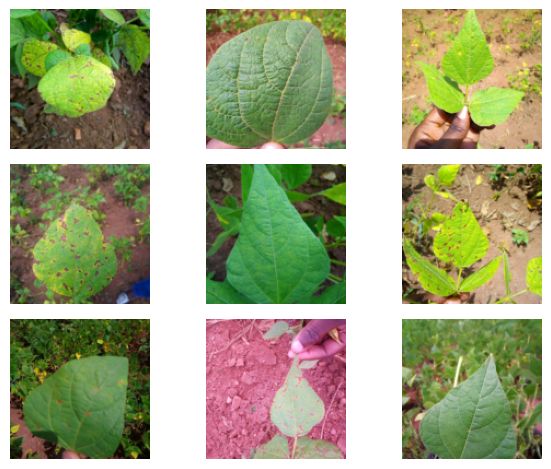

In [ ]:
f, axarr = plt.subplots(nrows=3, ncols=3)
for row in range(3):
  for col in range (3):
    image = train_dataset[np.random.randint(0, train_dataset.__len__())][0].cpu()
    axarr[row, col].imshow((image*255.0).squeeze().permute(1,2,0))
    axarr[row, col].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
LR =  1e-3
BATCH_SIZE = 4
EPOCHS = 15


In [ ]:
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=True)

In [ ]:
googlenet_model = models.googlenet(weights='DEFAULT')


Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 71.7MB/s]


In [ ]:
for param in googlenet_model.parameters():
  param.requires_grad = True

In [ ]:
googlenet_model.fc

Linear(in_features=1024, out_features=1000, bias=True)

In [ ]:
num_classes = len(train_df['category'].unique())
num_classes

3

In [ ]:
googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
googlenet_model.fc

Linear(in_features=1024, out_features=3, bias=True)

In [ ]:
googlenet_model.to(device)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [ ]:
criterion =  nn.CrossEntropyLoss()
optimizer = Adam(googlenet_model.parameters(), lr=LR)



In [ ]:
total_loss_train_plot = []
total_acc_train_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0

  for (inputs, labels) in train_loader:
    optimizer.zero_grad()
    outputs = googlenet_model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()
    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
    total_acc_train += train_acc
    optimizer.step()

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
  print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}%')

Epoch 1/15, Train Loss: 2.4754 Train Accuracy 53.1915%
Epoch 2/15, Train Loss: 2.2607 Train Accuracy 59.7679%
Epoch 3/15, Train Loss: 1.9651 Train Accuracy 66.9246%
Epoch 4/15, Train Loss: 1.7783 Train Accuracy 70.5996%
Epoch 5/15, Train Loss: 1.9245 Train Accuracy 70.5029%
Epoch 6/15, Train Loss: 1.7533 Train Accuracy 70.5029%
Epoch 7/15, Train Loss: 1.5745 Train Accuracy 75.3385%
Epoch 8/15, Train Loss: 1.5572 Train Accuracy 76.8859%
Epoch 9/15, Train Loss: 1.3541 Train Accuracy 80.4642%
Epoch 10/15, Train Loss: 1.3422 Train Accuracy 79.4004%
Epoch 11/15, Train Loss: 1.3254 Train Accuracy 79.9807%
Epoch 12/15, Train Loss: 1.3281 Train Accuracy 80.6576%
Epoch 13/15, Train Loss: 1.1406 Train Accuracy 82.5919%
Epoch 14/15, Train Loss: 1.0048 Train Accuracy 85.2998%
Epoch 15/15, Train Loss: 1.021 Train Accuracy 84.8162%


In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for indx, (input, labels) in enumerate(val_loader):

    prediction = googlenet_model(input)

    acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
    total_acc_test += acc

print(f"Accuracy Score is: {round((total_acc_test/val_dataset.__len__())*100, 2)}%")


Accuracy Score is: 83.46%


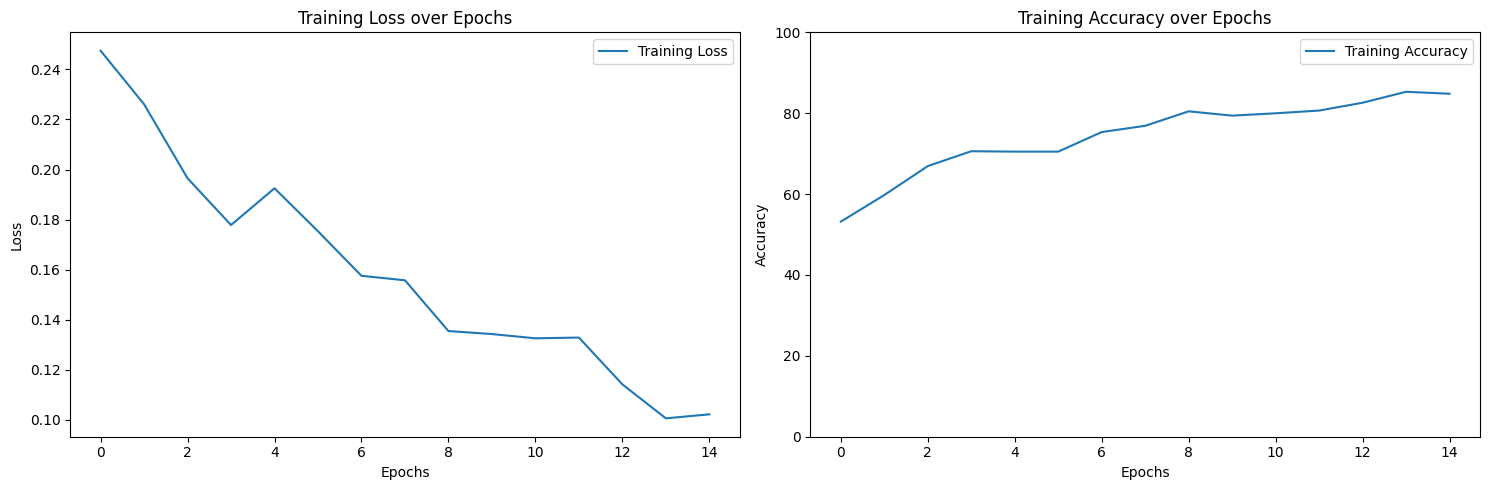

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].set_title('Training Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[1].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].set_title('Training Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()

In [1]:
# googlenet_model = models.googlenet(weights='DEFAULT')
# for param in googlenet_model.parameters():
#   param.requires_grad = False
# googlenet_model.fc = torch.nn.Linear(googlenet_model.fc.in_features, num_classes)
# googlenet_model.fc.requires_grad = True
# googlenet_model.to(device)


In [2]:
# total_loss_train_plot = []
# total_acc_train_plot = []

# for epoch in range(EPOCHS):
#   total_acc_train = 0
#   total_loss_train = 0

#   for (inputs, labels) in train_loader:
#     optimizer.zero_grad()
#     outputs = googlenet_model(inputs)
#     train_loss = criterion(outputs, labels)
#     total_loss_train += train_loss.item()
#     train_loss.backward()

#     train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()
#     total_acc_train += train_acc
#     optimizer.step()

#   total_loss_train_plot.append(round(total_loss_train/1000, 4))
#   total_acc_train_plot.append(round(total_acc_train/(train_dataset.__len__())*100, 4))
#   print(f'Epoch {epoch+1}/{EPOCHS}, Train Loss: {round(total_loss_train/100, 4)} Train Accuracy {round((total_acc_train)/train_dataset.__len__() * 100, 4)}%')

In [3]:
# with torch.no_grad():
#   total_loss_test = 0
#   total_acc_test = 0
#   for indx, (input, labels) in enumerate(val_loader):

#     prediction = googlenet_model(input)

#     acc = (torch.argmax(prediction, axis = 1) == labels).sum().item()
#     total_acc_test += acc

# print(f"Accuracy Score is: {round((total_acc_test/val_dataset.__len__())*100, 2)}%")


In [4]:
# print(round(total_acc_test/val_dataset.__len__()*100, 2))